# 06 — Gesture Rate and Speed

Quantifies **how often and how fast the subject gestures with their hands** during the video. Related trust literature: faster/more frequent gestures often read as more engaged and confident; in some studies faster gesture tempo is rated more trustworthy.

**Signal source:** MediaPipe Pose wrist landmarks (`mp_pose_l_wrist_*`, `mp_pose_r_wrist_*`), normalized 0–1 frame coordinates.

**What's computed:**
- Per-frame wrist velocity in normalized-units/sec (2D Euclidean).
- Gesture events — contiguous frames where velocity exceeds a threshold for at least `MIN_DURATION_MS`.
- Per-event metrics: start/end, duration, peak velocity.
- Video-level summary: gestures/min, mean peak velocity, total time gesturing.

**Input:** `data/<video>_merged.parquet` from `00_pipeline.ipynb`.  
**Outputs:** summary stats, per-event table, velocity plot with event shading, saved parquet.

---

### ⚠ Framing caveat — read this first

MediaPipe Pose always emits wrist coordinates, even when the hands are **not visible in frame** — it extrapolates their likely position from the visible parts of the body. Those extrapolated coords have very low **visibility** (<0.1) and are not trustworthy.

This notebook gates on the `_v` visibility field. If most frames have low visibility (e.g. head-and-shoulders interview video), the gesture metric is **not meaningful** and the notebook will flag this loudly in Section 1.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)

## Config

In [2]:
VIDEO_STEM = "sample"

VELOCITY_THRESHOLD = 0.3    # normalized-units / sec — per ticket spec
MIN_DURATION_MS = 200       # gesture must last at least this long
MIN_VISIBILITY = 0.5        # drop frames where wrist visibility is below this

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
PARQUET_PATH = DATA_DIR / f"{VIDEO_STEM}_merged.parquet"
META_PATH = DATA_DIR / f"{VIDEO_STEM}_merged.meta.json"
OUT_PATH = DATA_DIR / f"{VIDEO_STEM}_gestures.parquet"

print("Input :", PARQUET_PATH)
print("Output:", OUT_PATH)

Input : /Users/atharvumap/Documents/Projects/PyfeatTesting/data/sample_merged.parquet
Output: /Users/atharvumap/Documents/Projects/PyfeatTesting/data/sample_gestures.parquet


In [3]:
df = pd.read_parquet(PARQUET_PATH)
meta = pd.read_json(META_PATH, typ="series")
FPS = float(meta["effective_fps"])
frame_duration_s = 1.0 / FPS
print(f"{len(df)} sampled frames, effective fps = {FPS:.2f}")

165 sampled frames, effective fps = 6.00


## 1. Visibility check

**What this section does:** inspects MediaPipe's per-frame visibility score for each wrist. If most frames have visibility below `MIN_VISIBILITY`, the hands are likely out of frame or occluded — and downstream gesture numbers should not be trusted.

**Rule of thumb:**
- `pct_visible > 70%` → reliable gesture detection.
- `pct_visible 30–70%` → partial — expect undercounting of gestures made when hands were out of frame.
- `pct_visible < 30%` → the video doesn't show hands; gesture metrics are meaningless. Consider reshooting with wider framing or skipping this metric for this video.

In [4]:
vis_l = df["mp_pose_l_wrist_v"]
vis_r = df["mp_pose_r_wrist_v"]

vis_diag = pd.DataFrame({
    "wrist": ["left", "right"],
    "mean_visibility": [round(float(vis_l.mean()), 3), round(float(vis_r.mean()), 3)],
    "max_visibility": [round(float(vis_l.max()), 3), round(float(vis_r.max()), 3)],
    "pct_visible": [
        round(100 * float((vis_l > MIN_VISIBILITY).mean()), 1),
        round(100 * float((vis_r > MIN_VISIBILITY).mean()), 1),
    ],
})
print(vis_diag.to_string(index=False))

any_visible = (vis_l > MIN_VISIBILITY).any() or (vis_r > MIN_VISIBILITY).any()
if not any_visible:
    print("\n⚠ WARNING: no frames exceed the visibility threshold.")
    print("  The subject's hands are likely not in the video frame.")
    print("  All downstream gesture metrics will be 0 or NaN.")
elif max(vis_diag["pct_visible"]) < 30:
    print("\n⚠ WARNING: very low visibility. Gesture metrics are unreliable for this video.")

wrist  mean_visibility  max_visibility  pct_visible
 left            0.035           0.094          0.0
right            0.056           0.066          0.0

⚠ WARNING: no frames exceed the visibility threshold.
  The subject's hands are likely not in the video frame.
  All downstream gesture metrics will be 0 or NaN.


## 2. Wrist velocity per frame

**What this section does:** computes how fast each wrist is moving at each frame, in normalized-frame-width units per second.

**Formula (per wrist, per frame):**
$$v_t = \frac{\sqrt{(\Delta x_t)^2 + (\Delta y_t)^2}}{\Delta t}$$

where `Δx_t = wrist_x[t] − wrist_x[t−1]` and `Δt = 1/FPS`.

**Why 2D (x, y) and not 3D (x, y, z):** MediaPipe's `z` is a model-predicted depth from a single camera and is much noisier than `x`/`y`. 2D frame-plane motion is what a human observer sees and what gesture literature is defined against.

**Visibility gating:** frames with visibility below `MIN_VISIBILITY` have their velocity set to NaN — they don't count as either gesturing or not-gesturing.

**Units reminder:** 1.0 normalized-unit = full frame width (for x) or full frame height (for y). So `velocity = 0.5/sec` means the wrist traversed half the frame per second.

In [5]:
def wrist_velocity(df, side: str, vis_threshold: float):
    x = df[f"mp_pose_{side}_wrist_x"].where(df[f"mp_pose_{side}_wrist_v"] > vis_threshold)
    y = df[f"mp_pose_{side}_wrist_y"].where(df[f"mp_pose_{side}_wrist_v"] > vis_threshold)
    dx = x.diff()
    dy = y.diff()
    v = np.sqrt(dx * dx + dy * dy) / frame_duration_s
    return v

g = df[["frame", "timestamp"]].copy()
g["vel_l"] = wrist_velocity(df, "l", MIN_VISIBILITY)
g["vel_r"] = wrist_velocity(df, "r", MIN_VISIBILITY)
# Use max of the two wrists as the per-frame gesture velocity
g["vel"] = g[["vel_l", "vel_r"]].max(axis=1)

print(g[["vel_l", "vel_r", "vel"]].describe().round(3))

       vel_l  vel_r  vel
count    0.0    0.0  0.0
mean     NaN    NaN  NaN
std      NaN    NaN  NaN
min      NaN    NaN  NaN
25%      NaN    NaN  NaN
50%      NaN    NaN  NaN
75%      NaN    NaN  NaN
max      NaN    NaN  NaN


## 3. Detect gesture events

**What this section does:** converts the continuous velocity signal into a list of discrete gesture events.

**Event definition:** a contiguous run of frames where `vel > VELOCITY_THRESHOLD`, lasting at least `MIN_DURATION_MS`.

**Why the minimum duration:** single-frame velocity spikes are usually landmark jitter, not actual gestures. Real gestures (pointing, illustrating, beat gestures) last at least 200–300 ms.

**Why "max of L/R wrist" as the event driver:** a gesture counts if *either* hand is moving — counting L and R separately would double-count bilateral gestures. For studies where handedness matters, split them.

**Per-event metrics stored:**
- `start_time`, `end_time`, `duration_s`
- `peak_velocity` — the max velocity observed during the event. Peak is the standard gesture-tempo metric in the literature, more informative than mean (fast beats near gesture apex dominate perception of gesture speed).

In [6]:
def find_events(mask: np.ndarray):
    mask = np.asarray(mask).astype(bool)
    if mask.size == 0:
        return []
    diff = np.diff(mask.astype(int), prepend=0, append=0)
    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0] - 1
    return list(zip(starts.tolist(), ends.tolist()))

vel = g["vel"].to_numpy()
ts = g["timestamp"].to_numpy()
above = np.where(np.isnan(vel), False, vel > VELOCITY_THRESHOLD)
raw_runs = find_events(above)

rows = []
for s, e in raw_runs:
    dur_s = float(ts[e] - ts[s] + frame_duration_s)
    if dur_s * 1000 < MIN_DURATION_MS:
        continue
    peak = float(np.nanmax(vel[s:e+1]))
    rows.append({
        "start_time": round(float(ts[s]), 2),
        "end_time": round(float(ts[e]), 2),
        "duration_s": round(dur_s, 2),
        "peak_velocity": round(peak, 3),
    })

events_df = pd.DataFrame(rows)
print(f"Detected {len(events_df)} gesture events (from {len(raw_runs)} raw runs).")
events_df

Detected 0 gesture events (from 0 raw runs).


""


## 4. Summary stats

The video-level headline numbers.

**What each means:**
- `gestures_per_minute` — event rate, normalized. For cross-video comparison.
- `mean_peak_velocity` — average of per-event peak velocities. The "speed" measure — correlates with perceived gesture energy.
- `total_time_gesturing_s` — cumulative event duration.
- `pct_time_gesturing` — event time / video duration × 100.

In [7]:
dur_total_s = len(g) * frame_duration_s
n_ev = len(events_df)
total_gest_s = float(events_df["duration_s"].sum()) if n_ev else 0.0
mean_peak = float(events_df["peak_velocity"].mean()) if n_ev else float("nan")

summary = pd.Series({
    "duration_s": round(dur_total_s, 2),
    "n_gestures": n_ev,
    "gestures_per_minute": round(60 * n_ev / dur_total_s, 2) if dur_total_s else float("nan"),
    "mean_peak_velocity": round(mean_peak, 3) if not np.isnan(mean_peak) else float("nan"),
    "total_time_gesturing_s": round(total_gest_s, 2),
    "pct_time_gesturing": round(100 * total_gest_s / dur_total_s, 1) if dur_total_s else float("nan"),
    "velocity_threshold": VELOCITY_THRESHOLD,
    "visibility_gate": MIN_VISIBILITY,
})
summary

duration_s                27.5
n_gestures                 0.0
gestures_per_minute        0.0
mean_peak_velocity         NaN
total_time_gesturing_s     0.0
pct_time_gesturing         0.0
velocity_threshold         0.3
visibility_gate            0.5
dtype: float64

## 5. Velocity-over-time plot with events shaded

**Top panel:** per-wrist velocity traces. Helps you see which hand is doing the moving (useful for handedness / asymmetry questions).

**Bottom panel:** the max-of-both velocity signal (the one we threshold), with horizontal threshold line and green-shaded detected events.

**What to look for:**
- Events cleanly over the threshold line → detector is working.
- Noisy bouncing around the threshold → threshold too close to noise floor; raise it.
- Events that visually look like gestures but weren't caught → lower the threshold or lower `MIN_DURATION_MS`.

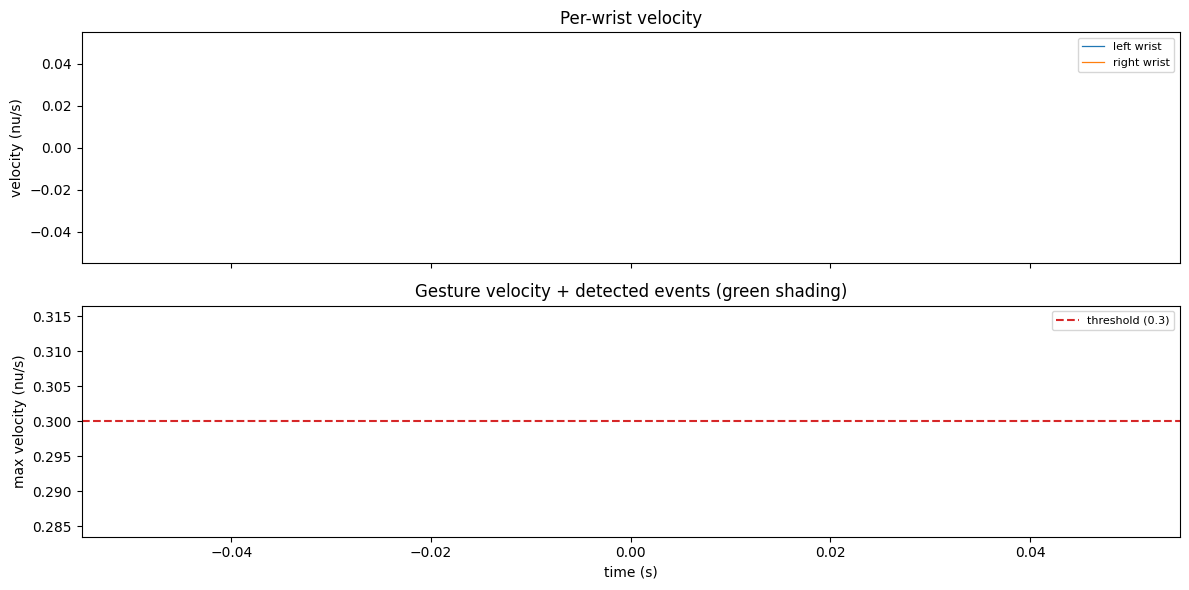

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(ts, g["vel_l"], color="tab:blue", label="left wrist", lw=0.9)
axes[0].plot(ts, g["vel_r"], color="tab:orange", label="right wrist", lw=0.9)
axes[0].set_ylabel("velocity (nu/s)")
axes[0].legend(loc="upper right", fontsize=8)
axes[0].set_title("Per-wrist velocity")

axes[1].plot(ts, g["vel"], color="tab:gray", lw=1.0)
axes[1].axhline(VELOCITY_THRESHOLD, color="tab:red", ls="--", label=f"threshold ({VELOCITY_THRESHOLD})")
for _, ev in events_df.iterrows():
    axes[1].axvspan(ev["start_time"], ev["end_time"] + frame_duration_s, color="tab:green", alpha=0.2)
axes[1].set_xlabel("time (s)")
axes[1].set_ylabel("max velocity (nu/s)")
axes[1].legend(loc="upper right", fontsize=8)
axes[1].set_title("Gesture velocity + detected events (green shading)")

plt.tight_layout()
plt.show()

## 6. Save per-frame gesture parquet

In [9]:
out = g[["frame", "timestamp", "vel_l", "vel_r", "vel"]].copy()
out["is_gesturing"] = np.where(np.isnan(out["vel"]), False, out["vel"] > VELOCITY_THRESHOLD)
out.to_parquet(OUT_PATH, index=False)
print(f"Saved: {OUT_PATH}  ({len(out)} rows, {int(out['is_gesturing'].sum())} high-velocity frames)")

Saved: /Users/atharvumap/Documents/Projects/PyfeatTesting/data/sample_gestures.parquet  (165 rows, 0 high-velocity frames)
